# 01 · Análisis exploratorio de datos

## Predicción del riesgo de rotura de stock en un entorno logístico

En este notebook realizo el análisis exploratorio del dataset de ventas.

Mi objetivo es conocer la estructura de los datos, revisar su calidad y buscar patrones que puedan ser útiles para construir posteriormente un modelo de predicción del riesgo de rotura de stock.

En esta fase todavía no creo el target ni entreno modelos. Primero necesito entender correctamente la información disponible.


## 1. Importación de librerías

Importo las librerías principales que voy a utilizar:

- `pandas` para trabajar con tablas.
- `numpy` para algunos cálculos numéricos.
- `matplotlib` y `seaborn` para crear gráficos.
- `Path` para trabajar con las rutas de los archivos.


In [79]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. Definición de rutas

Utilizo rutas relativas para mantener la estructura del proyecto.

Primero compruebo si el notebook se está ejecutando desde la carpeta `notebooks`. Si no es así, utilizo la carpeta actual como raíz del proyecto.

También creo las carpetas donde guardaré las tablas y las imágenes generadas durante el EDA.


In [80]:
# Compruebo desde qué carpeta se está ejecutando el notebook.
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = current_path

data_path = project_path / "data" / "raw" / "retail_sales.csv"
figures_path = project_path / "outputs" / "figures" / "eda"
tables_path = project_path / "outputs" / "tables" / "eda"

# Creo las carpetas de salida si todavía no existen.
figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

print("Ruta del proyecto:", project_path)
print("Ruta del dataset:", data_path)


Ruta del proyecto: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1
Ruta del dataset: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\raw\retail_sales.csv


## 3. Carga del dataset

Antes de cargar los datos compruebo que el archivo existe.

Después muestro el número de filas, columnas y los primeros registros. Esto me permite confirmar que la lectura se ha realizado correctamente.


In [81]:
if not data_path.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo: {data_path}"
    )

df = pd.read_csv(data_path)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

display(df.head())


Filas: 4,565,000
Columnas: 8


,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


## 4. Revisión inicial de la estructura

Reviso los nombres de las columnas, sus tipos de datos y la cantidad de valores no nulos.

Este paso es importante porque un CSV puede guardar fechas o números como texto. Si los tipos no son correctos, los cálculos posteriores podrían fallar.


In [82]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   store_id  str    
 2   item_id   str    
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 278.6 MB


## 5. Conversión de tipos

Convierto la columna `date` a formato fecha.

También convierto las variables principales a formato numérico. Si algún valor no puede convertirse, se transforma en nulo para poder detectarlo en la revisión de calidad.


In [83]:
# Convierto únicamente las columnas que realmente son numéricas.
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

numeric_columns = [
    "sales",
    "price",
    "promo"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Mantengo tienda y producto como identificadores de texto.
df["store_id"] = df["store_id"].astype(str)
df["item_id"] = df["item_id"].astype(str)

print(df.dtypes)
display(df.head())


date        datetime64[us]
store_id               str
item_id                str
sales                int64
price              float64
promo                int64
weekday              int64
month                int64
dtype: object


,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


## 6. Calidad de los datos

Creo una tabla con el tipo de cada columna, los valores ausentes y la cantidad de valores distintos.

La finalidad es detectar problemas básicos antes de realizar gráficos o cálculos.


In [84]:
quality_report = pd.DataFrame({
    "column": df.columns, #columnas
    "dtype": df.dtypes.astype(str).values, #tipo de campo
    "missing_values": df.isna().sum().values, #valores faltantes
    "missing_pct": (df.isna().mean() * 100).round(2).values, #porcentaje de valores faltantes
    "unique_values": df.nunique().values #valores únicos
})

quality_report = quality_report.sort_values(
    "missing_pct",
    ascending=False
)

display(quality_report)

quality_report.to_csv(
    tables_path / "quality_report.csv",
    index=False
)


,column,dtype,missing_values,missing_pct,unique_values
0,date,datetime64[us],0,0.00,1826
1,store_id,str,0,0.00,50
2,item_id,str,0,0.00,50
3,sales,int64,0,0.00,139
4,price,float64,0,0.00,3798
5,promo,int64,0,0.00,2
6,weekday,int64,0,0.00,7
7,month,int64,0,0.00,12


### Duplicados

Compruebo dos tipos de duplicados:

1. Filas completamente repetidas.
2. Varias observaciones para la misma fecha, tienda y producto.

No elimino registros automáticamente porque primero tendría que conocer la causa. Podrían ser errores, pero también podrían necesitar una agregación.


In [85]:
exact_duplicates = df.duplicated().sum()

business_key = ["date", "store_id", "item_id"]
business_duplicates = df.duplicated(
    subset=business_key
).sum()

print(f"Duplicados exactos: {exact_duplicates:,}")
print(
    "Duplicados por fecha, tienda y producto:",
    f"{business_duplicates:,}"
)


Duplicados exactos: 0
Duplicados por fecha, tienda y producto: 0


### Comprobaciones básicas

Reviso si existen ventas negativas, precios iguales o inferiores a cero y valores de promoción distintos de 0 y 1.

Estas reglas me ayudan a detectar datos que podrían no tener sentido dentro del problema.


In [86]:
basic_checks = pd.Series({
    "dates_missing": df["date"].isna().sum(),
    "sales_missing": df["sales"].isna().sum(),
    "negative_sales": (df["sales"] < 0).sum(),
    "non_positive_prices": (df["price"] <= 0).sum(),
    "invalid_promo_values": (~df["promo"].isin([0, 1])).sum()
}, name="count")

display(basic_checks.to_frame())

basic_checks.to_csv(
    tables_path / "basic_checks.csv",
    header=True
)


,count
dates_missing,0
sales_missing,0
negative_sales,0
non_positive_prices,0
invalid_promo_values,0


## 7. Resumen estadístico

Utilizo `describe()` para conocer los valores mínimos, máximos, medias y percentiles de las variables numéricas.

Este resumen me ayuda a entender la escala de los datos y a detectar posibles valores extremos.


In [87]:
numeric_summary = df[
    ["sales", "price", "promo"]
].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

display(numeric_summary)

numeric_summary.to_csv(
    tables_path / "numeric_summary.csv"
)


,count,mean,std,min,1%,5%,50%,95%,99%,max
sales,"4,565,000.00",29.26,15.01,0.00,6.00,10.00,27.00,57.00,73.00,139.00
price,"4,565,000.00",53.99,25.78,8.02,10.80,14.27,53.52,95.34,98.95,99.99
promo,"4,565,000.00",0.10,0.30,0.00,0.00,0.00,0.00,1.00,1.00,1.00


## 8. Cobertura temporal

Compruebo el periodo cubierto por el dataset y el número de fechas diferentes.

También reviso si faltan días completos entre la primera y la última fecha. Esta información será importante más adelante, porque los lags y las medias móviles dependen del orden temporal.


In [88]:
date_min = df["date"].min()
date_max = df["date"].max()

expected_dates = pd.date_range(
    start=date_min,
    end=date_max,
    freq="D"
)

observed_dates = df["date"].nunique()
missing_dates = len(expected_dates) - observed_dates

print("Primera fecha:", date_min)
print("Última fecha:", date_max)
print("Fechas observadas:", observed_dates)
print("Días completamente ausentes:", missing_dates)


Primera fecha: 2019-01-01 00:00:00
Última fecha: 2023-12-31 00:00:00
Fechas observadas: 1826
Días completamente ausentes: 0


## 9. Creación de variables temporales

A partir de la fecha creo variables sencillas como año, mes y día de la semana.

Estas variables me permiten estudiar si las ventas cambian según el momento del año o el día.


In [89]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.dayofweek

weekday_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df["weekday_name"] = df["weekday"].map(
    weekday_names
)


## 10. Evolución temporal de las ventas

Agrupo las ventas por fecha para obtener una visión general.

Además de las ventas diarias, calculo medias móviles de 7 y 30 días. Estas medias suavizan las variaciones diarias y facilitan la observación de tendencias.


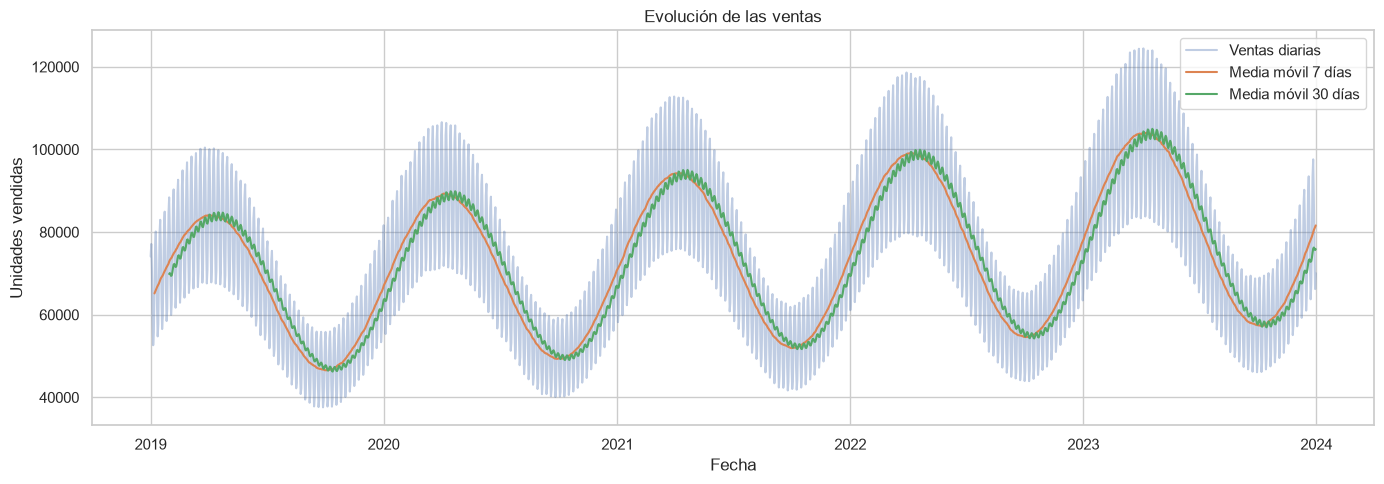

In [90]:
daily_sales = (
    df.groupby("date", as_index=False)
      .agg(total_sales=("sales", "sum"))
      .sort_values("date")
)

daily_sales["rolling_mean_7"] = (
    daily_sales["total_sales"]
    .rolling(window=7)
    .mean()
)

daily_sales["rolling_mean_30"] = (
    daily_sales["total_sales"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    alpha=0.35,
    label="Ventas diarias"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_7"],
    label="Media móvil 7 días"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_30"],
    label="Media móvil 30 días"
)

plt.title("Evolución de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "evolucion_ventas.png",
    dpi=150
)

plt.show()


## 11. Ventas por mes

Calculo las ventas medias de cada mes para comprobar si existe un patrón estacional.

Utilizo la media porque quiero comparar el comportamiento habitual de los meses, no solo el volumen total acumulado.


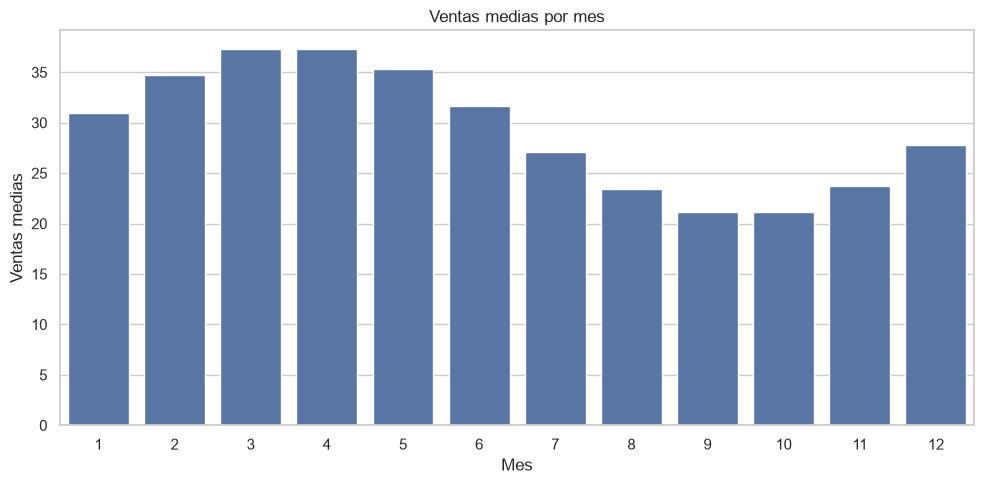

In [91]:
monthly_sales = (
    df.groupby("month", as_index=False)
      .agg(
          average_sales=("sales", "mean"),
          total_sales=("sales", "sum")
      )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_sales,
    x="month",
    y="average_sales",
    errorbar=None
)

plt.title("Ventas medias por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas medias")
plt.tight_layout()

plt.savefig(
    figures_path / "ventas_medias_mes.png",
    dpi=150
)

plt.show()


## 12. Ventas por día de la semana

Agrupo las ventas por día de la semana para comprobar si existen diferencias entre días laborables y fines de semana.


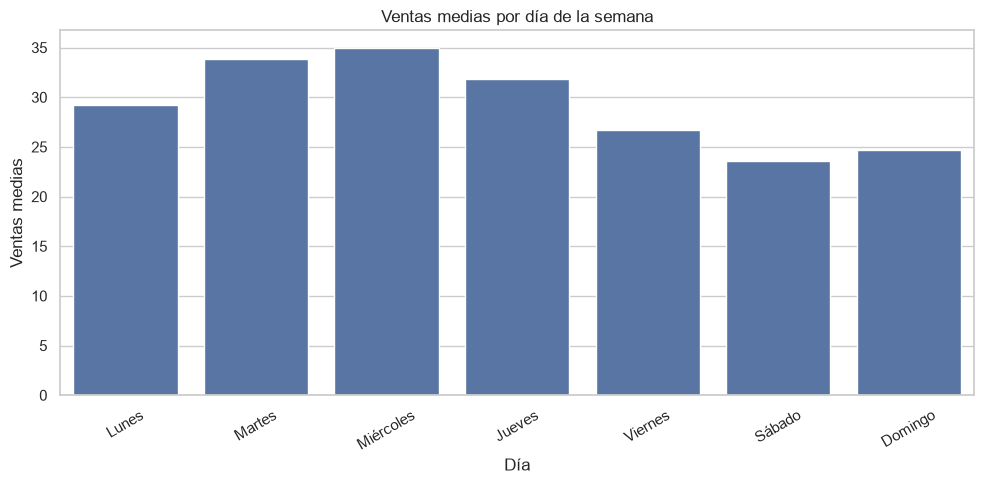

In [92]:
weekday_sales = (
    df.groupby(
        ["weekday", "weekday_name"],
        as_index=False
    )
    .agg(average_sales=("sales", "mean"))
    .sort_values("weekday")
)

weekday_order = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_sales,
    x="weekday_name",
    y="average_sales",
    order=weekday_order,
    errorbar=None
)

plt.title("Ventas medias por día de la semana")
plt.xlabel("Día")
plt.ylabel("Ventas medias")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    figures_path / "ventas_medias_semana.png",
    dpi=150
)

plt.show()


## 13. Análisis por tienda y producto

No todas las tiendas ni todos los productos tienen el mismo nivel de ventas.

Agrupo la información para identificar las tiendas y productos con mayor volumen.


In [93]:
print("Shape de df:", df.shape)
print(df.head())

Shape de df: (4565000, 10)
        date store_id item_id  sales  price  promo  weekday  month  year  \
0 2019-01-01  store_1  item_1     41  21.30      0        1      1  2019   
1 2019-01-02  store_1  item_1     53  21.30      0        2      1  2019   
2 2019-01-03  store_1  item_1     39  21.30      0        3      1  2019   
3 2019-01-04  store_1  item_1     35  21.30      0        4      1  2019   
4 2019-01-05  store_1  item_1     51  17.04      1        5      1  2019   

  weekday_name  
0       Martes  
1    Miércoles  
2       Jueves  
3      Viernes  
4       Sábado  


In [94]:
store_sales = (
    df.groupby("store_id", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          average_sales=("sales", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

product_sales = (
    df.groupby("item_id", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          average_sales=("sales", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

print("Tiendas con más ventas")
print(store_sales.head(10))

print("\nProductos con más ventas")
print(product_sales.head(10))


Tiendas con más ventas
    store_id  total_sales  average_sales
3   store_12      3243496          35.53
28  store_35      3240494          35.49
11   store_2      3221215          35.28
27  store_34      3218908          35.26
38  store_44      3179667          34.83
48   store_8      3132417          34.31
4   store_13      3094882          33.90
29  store_36      3069321          33.62
18  store_26      3041146          33.31
22   store_3      2983937          32.68

Productos con más ventas
    item_id  total_sales  average_sales
12  item_20      4261507          46.68
0    item_1      4207065          46.08
22   item_3      4108554          45.00
46   item_6      4051413          44.37
33   item_4      3964580          43.42
32  item_39      3938555          43.14
24  item_31      3861901          42.30
4   item_13      3752355          41.10
16  item_24      3710934          40.65
9   item_18      3665037          40.14


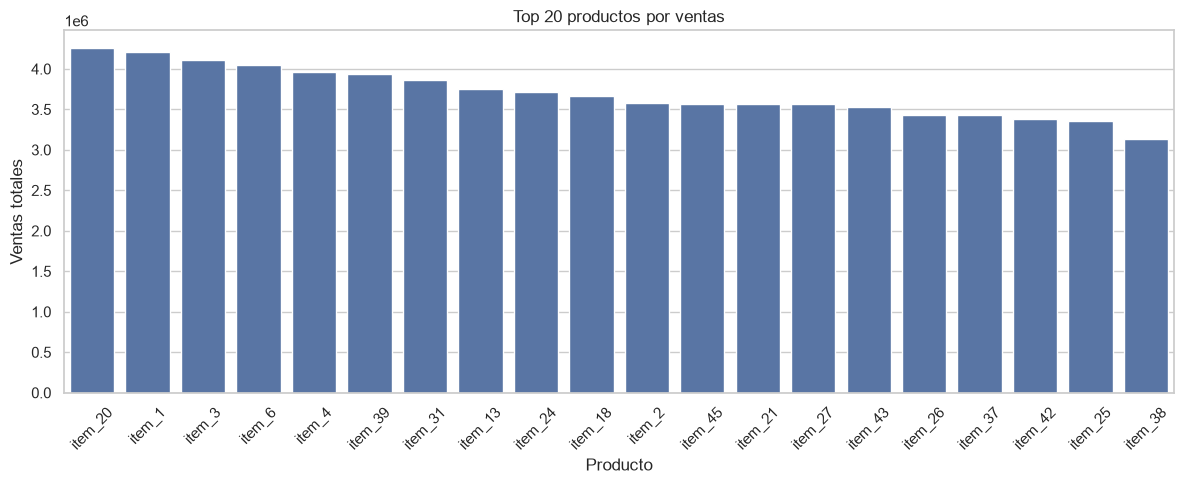

In [95]:
top_products = product_sales.head(20)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_products,
    x="item_id",
    y="total_sales",
    errorbar=None
)

plt.title("Top 20 productos por ventas")
plt.xlabel("Producto")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "top20_productos.png",
    dpi=150
)

plt.show()


## 14. Distribución de las ventas

Reviso cómo se distribuyen las ventas y cuántos registros tienen ventas iguales a cero.

Una venta igual a cero no significa necesariamente que exista una rotura de stock. También puede significar que no hubo demanda. Por este motivo, no utilizaré directamente los ceros como target.


In [96]:
sales_percentiles = df["sales"].quantile(
    [0, 0.01, 0.05, 0.50, 0.95, 0.99, 1]
)

display(
    sales_percentiles.to_frame("sales")
)

zero_sales_count = (df["sales"] == 0).sum()
zero_sales_pct = (
    df["sales"].eq(0).mean() * 100
)

print(
    f"Ventas iguales a cero: "
    f"{zero_sales_count:,} "
    f"({zero_sales_pct:.2f} %)"
)


,sales
0.00,0.00
0.01,6.00
0.05,10.00
0.50,27.00
0.95,57.00
0.99,73.00
1.00,139.00


Ventas iguales a cero: 1,037 (0.02 %)


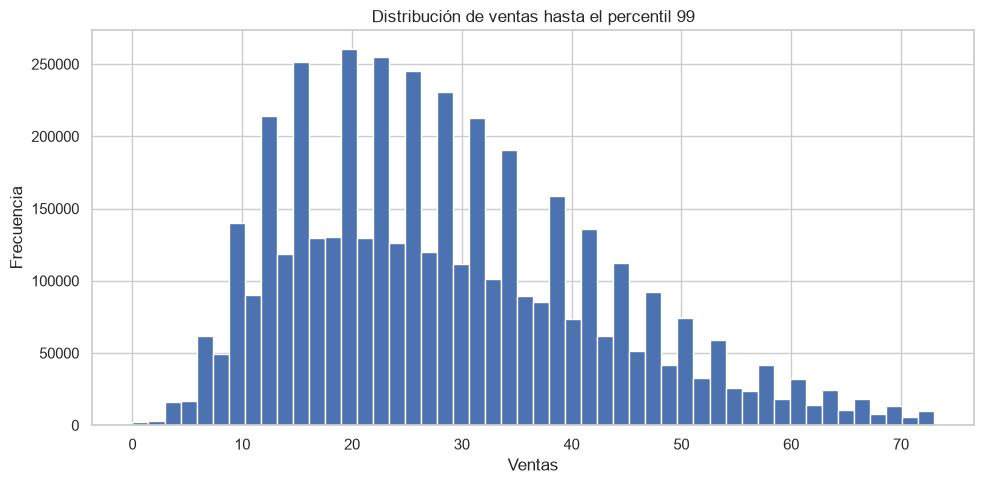

In [97]:
sales_limit = df["sales"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[
        df["sales"] <= sales_limit,
        "sales"
    ],
    bins=50
)

plt.title("Distribución de ventas hasta el percentil 99")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig(
    figures_path / "distribucion_ventas.png",
    dpi=150
)

plt.show()


## 15. Análisis del precio

Reviso la distribución del precio para conocer su rango habitual y detectar posibles valores extremos.

El precio puede influir en la demanda y se utilizará posteriormente como variable del modelo.


In [ ]:
# Reviso los principales valores estadísticos del precio.
display(
    df["price"].describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    ).to_frame()
)

# Utilizo una muestra porque representar más de cuatro millones
# de registros haría el gráfico demasiado lento.
price_sample = df["price"].dropna().sample(
    n=min(50_000, df["price"].notna().sum()),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 5))

plt.hist(
    price_sample,
    bins=50
)

plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig(
    figures_path / "distribucion_precio.png",
    dpi=150
)

plt.show()


## 16. Análisis de promociones

Comparo las ventas medias con y sin promoción.

Este análisis es descriptivo. Una diferencia entre los dos grupos no demuestra que la promoción sea la única causa, porque también pueden influir el producto, la tienda, el precio o la época del año.


In [ ]:
promo_summary = (
    df.groupby("promo", as_index=False)
      .agg(
          average_sales=("sales", "mean"),
          median_sales=("sales", "median"),
          observations=("sales", "size")
      )
)

display(promo_summary)

promo_summary.to_csv(
    tables_path / "promo_summary.csv",
    index=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=promo_summary,
    x="promo",
    y="average_sales",
    errorbar=None
)

plt.title("Ventas medias con y sin promoción")
plt.xlabel("Promoción")
plt.ylabel("Ventas medias")
plt.tight_layout()

plt.savefig(
    figures_path / "ventas_promocion.png",
    dpi=150
)

plt.show()


## 17. Relación entre variables

Calculo una matriz de correlación para estudiar relaciones lineales entre las variables numéricas.

La correlación es solo una primera aproximación. Una correlación baja no significa que una variable no sea útil, porque pueden existir relaciones no lineales.


In [ ]:
correlation_columns = [
    "sales",
    "price",
    "promo",
    "month",
    "weekday"
]

correlation_matrix = df[
    correlation_columns
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")
plt.tight_layout()

plt.savefig(
    figures_path / "matriz_correlacion.png",
    dpi=150
)

plt.show()


## 18. Resumen final del EDA

Creo una tabla final con los principales indicadores del dataset.

Este resumen me permitirá reutilizar la información en el README y mantener las cifras actualizadas cada vez que ejecute el notebook.


In [ ]:
eda_summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "date_min": df["date"].min(),
    "date_max": df["date"].max(),
    "stores": df["store_id"].nunique(),
    "items": df["item_id"].nunique(),
    "total_sales": df["sales"].sum(),
    "average_sales": df["sales"].mean(),
    "zero_sales_pct": zero_sales_pct,
    "average_price": df["price"].mean(),
    "promo_rate_pct": df["promo"].mean() * 100,
    "exact_duplicates": exact_duplicates,
    "business_key_duplicates": business_duplicates,
    "missing_calendar_dates": missing_dates
}, name="value")

display(
    eda_summary.to_frame()
)

eda_summary.to_csv(
    tables_path / "eda_summary.csv",
    header=True
)
